<a href="https://colab.research.google.com/github/mayaallek/HDSModule5/blob/main/HDS_ML_MAYAALLEK_2606.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train: (181, 13) | Val: (61, 13) | Test: (61, 13)

=== COHORT CHARACTERISTICS ===
Total patients : 303
Disease        : 139 (45.9%)
No Disease     : 164 (54.1%)
Male           : 206 (68.0%)
Female         : 97 (32.0%)

=== TABLE 1: COHORT CHARACTERISTICS (Mean ± SD) ===


,No Disease,Disease,Overall
Feature,,,
Age (years),52.6 ± 9.5,56.6 ± 7.9,54.4 ± 9.0
Cholesterol (mg/dl),242.6 ± 53.5,251.5 ± 49.5,246.7 ± 51.8
Resting BP (mmHg),129.2 ± 16.2,134.6 ± 18.8,131.7 ± 17.6
Max Heart Rate,158.4 ± 19.2,139.3 ± 22.6,149.6 ± 22.9
ST Depression,0.6 ± 0.8,1.6 ± 1.3,1.0 ± 1.2
Male Sex (%),56.1%,82.0%,68.0%


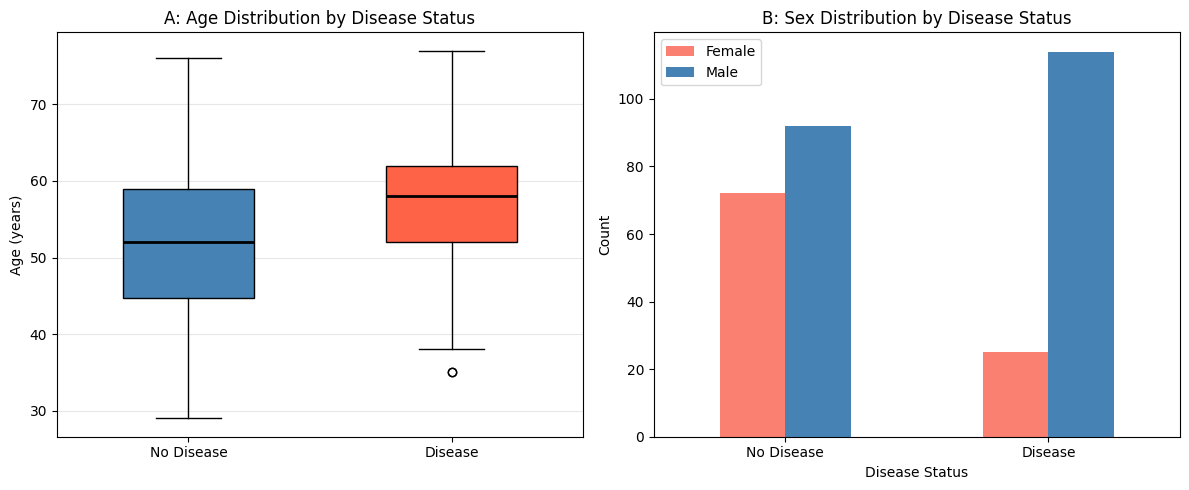

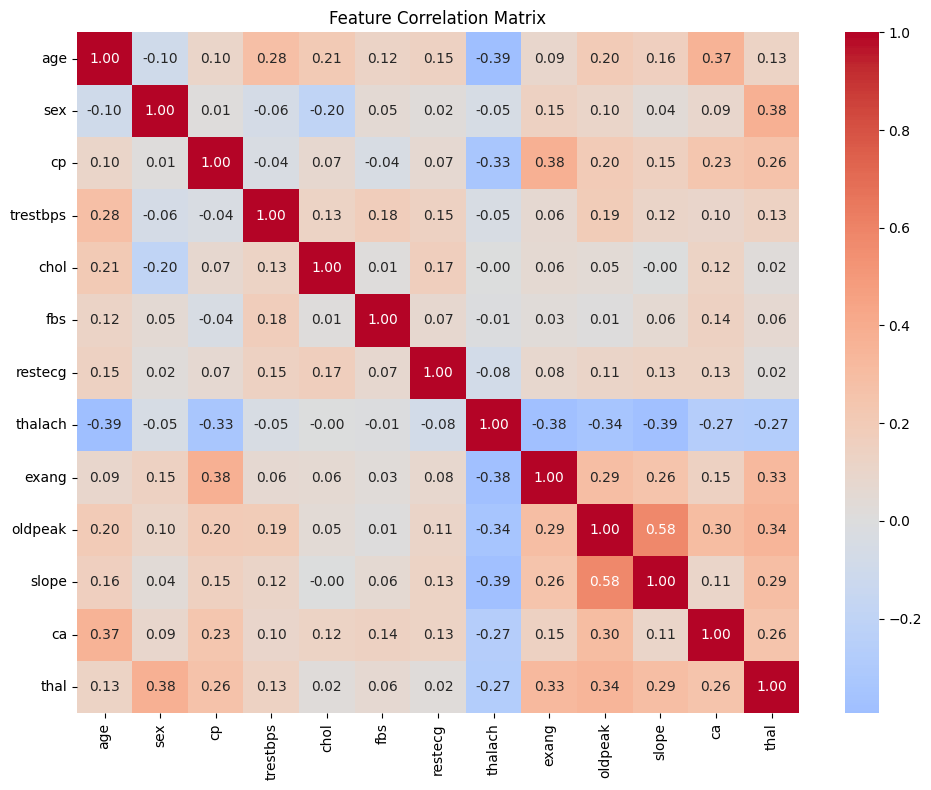

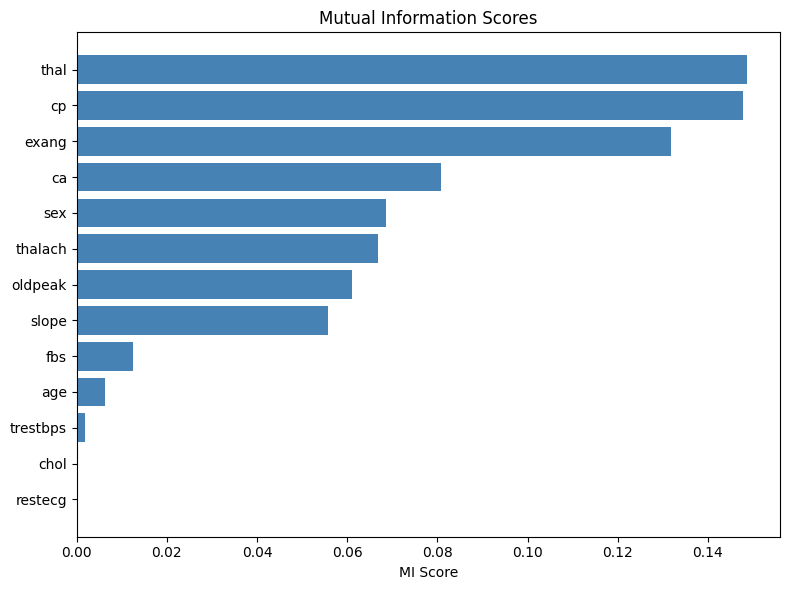

 Feature  MI Score
    thal  0.148552
      cp  0.147726
   exang  0.131815
      ca  0.080884
     sex  0.068598
 thalach  0.066769
 oldpeak  0.061119
   slope  0.055750
     fbs  0.012522
     age  0.006292
trestbps  0.001911
    chol  0.000000
 restecg  0.000000
=== Validation Results (Pre-Tuning) ===
LR  — Accuracy: 0.852 | AUC: 0.939
XGB — Accuracy: 0.754 | AUC: 0.881

Best XGBoost params : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best CV AUC         : 0.857

=== FINAL TEST RESULTS ===

Logistic Regression:
Accuracy: 0.885 | AUC: 0.952 | F1: 0.885
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61

XGBoost (Tuned):
Accuracy: 0.869 | AUC: 0.948 | F1: 0.862
              precision    recall  f

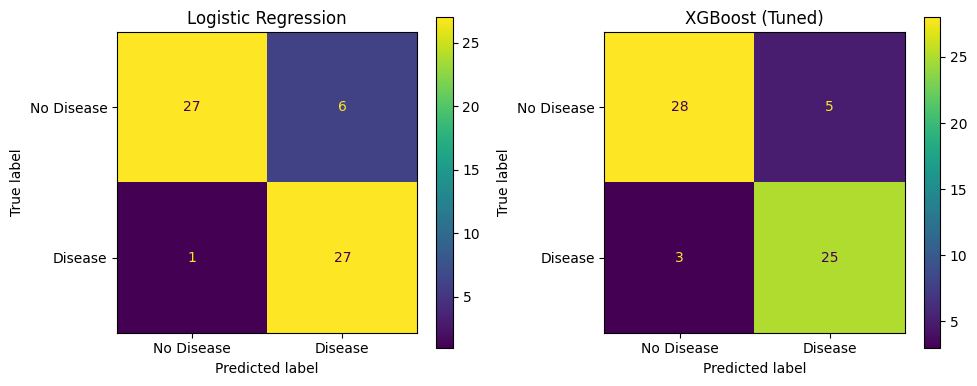

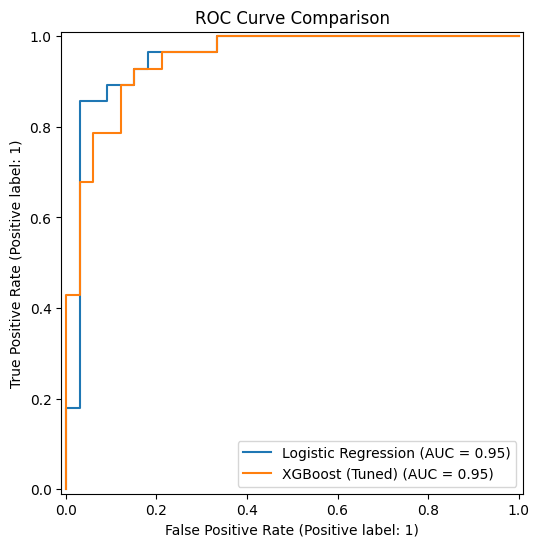

=== 10-Fold Cross-Validation AUC ===
Logistic Regression : 0.906 ± 0.049
XGBoost (Tuned)     : 0.898 ± 0.046

Wilcoxon p = 0.3750 — No significant difference


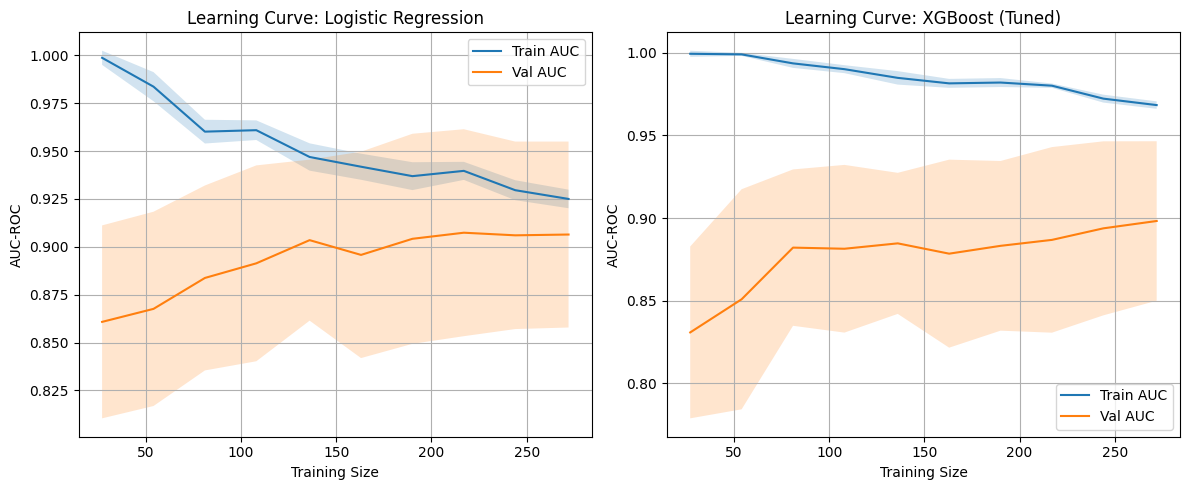

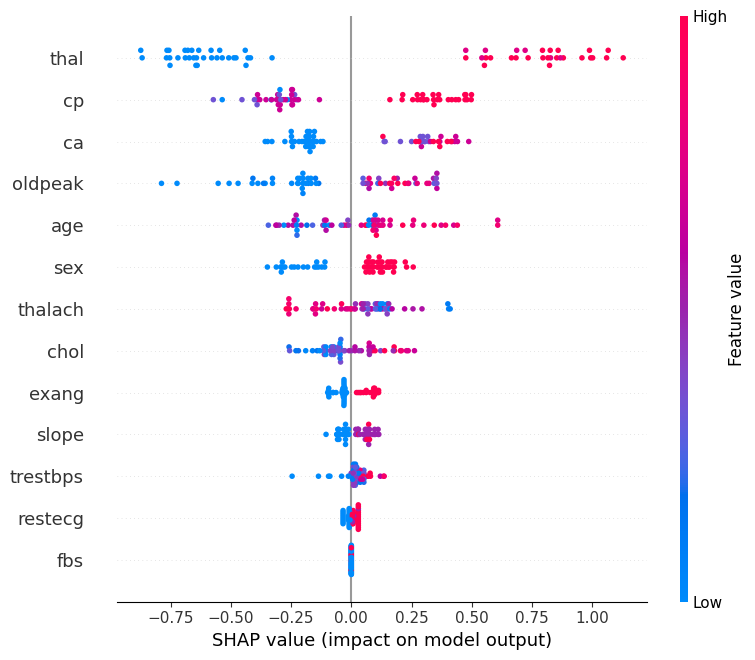

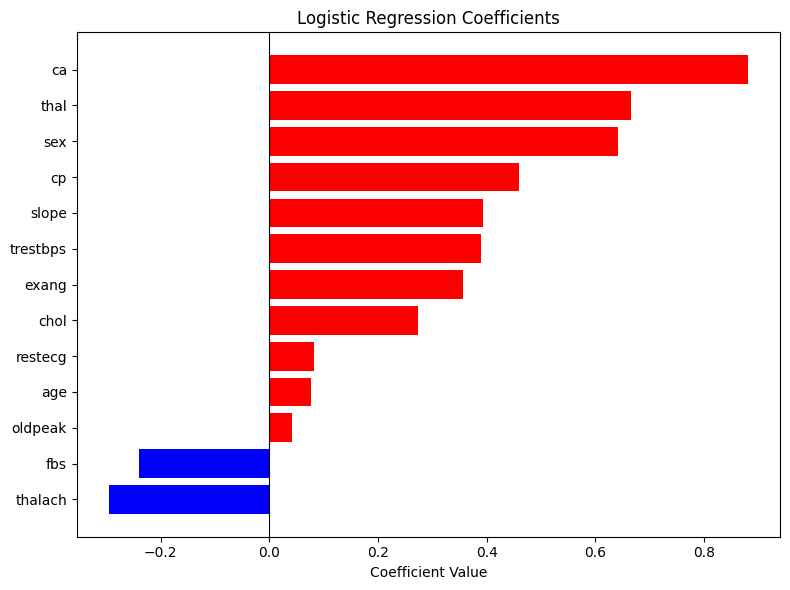

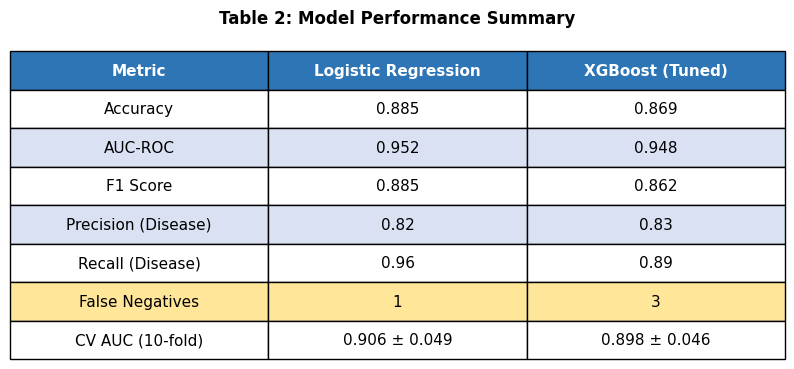

Mounted at /content/drive
All outputs saved to Google Drive.


In [15]:
# INSTALL & LOAD DATA
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score,
                                     learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from scipy.stats import wilcoxon

# PREPROCESSING
# Binarise target: 0 = no disease, 1–4 = disease
y_binary = (y['num'] > 0).astype(int)

# Impute missing values with column median
X_clean = X.fillna(X.median())

# Three-way stratified split: 60% train / 20% val / 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_clean, y_binary, test_size=0.2, random_state=42, stratify=y_binary)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

# Standardise — fit only on train to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# COHORT CHARACTERISTICS
df_summary = X_clean.copy()
df_summary['target'] = y_binary.values

print("\n=== COHORT CHARACTERISTICS ===")
print(f"Total patients : {len(df_summary)}")
print(f"Disease        : {y_binary.sum()} ({y_binary.mean()*100:.1f}%)")
print(f"No Disease     : {(y_binary==0).sum()} ({(y_binary==0).mean()*100:.1f}%)")
print(f"Male           : {(X_clean['sex']==1).sum()} ({(X_clean['sex']==1).mean()*100:.1f}%)")
print(f"Female         : {(X_clean['sex']==0).sum()} ({(X_clean['sex']==0).mean()*100:.1f}%)")

# Table 1 — mean ± SD per feature stratified by disease status
groups   = {'No Disease': df_summary[df_summary['target']==0],
            'Disease':    df_summary[df_summary['target']==1],
            'Overall':    df_summary}
features = {'Age (years)': 'age', 'Cholesterol (mg/dl)': 'chol',
            'Resting BP (mmHg)': 'trestbps', 'Max Heart Rate': 'thalach',
            'ST Depression': 'oldpeak'}
rows = []
for label, col in features.items():
    row = {'Feature': label}
    for gname, gdf in groups.items():
        row[gname] = f"{gdf[col].mean():.1f} ± {gdf[col].std():.1f}"
    rows.append(row)
row = {'Feature': 'Male Sex (%)'}
for gname, gdf in groups.items():
    row[gname] = f"{gdf['sex'].mean()*100:.1f}%"
rows.append(row)
table1 = pd.DataFrame(rows).set_index('Feature')
print("\n=== TABLE 1: COHORT CHARACTERISTICS (Mean ± SD) ===")
display(table1)

# Figure 1 — age boxplot & sex bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
data_to_plot = [df_summary[df_summary['target']==0]['age'],
                df_summary[df_summary['target']==1]['age']]
bp = axes[0].boxplot(data_to_plot, patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')
axes[0].set_xticklabels(['No Disease', 'Disease'])
axes[0].set_title('A: Age Distribution by Disease Status')
axes[0].set_ylabel('Age (years)')
axes[0].grid(axis='y', alpha=0.3)

sex_counts = df_summary.groupby(['target', 'sex']).size().unstack()
sex_counts.index   = ['No Disease', 'Disease']
sex_counts.columns = ['Female', 'Male']
sex_counts.plot(kind='bar', ax=axes[1], color=['salmon', 'steelblue'])
axes[1].set_title('B: Sex Distribution by Disease Status')
axes[1].set_xlabel('Disease Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('figure1_cohort.png', dpi=150)
plt.show()

# Pearson correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(X_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('figure2_correlation.png', dpi=150)
plt.show()

# Mutual information scores (training set only)
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores}).sort_values('MI Score', ascending=True)
plt.figure(figsize=(8, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue')
plt.title('Mutual Information Scores')
plt.xlabel('MI Score')
plt.tight_layout()
plt.savefig('figure3_mutual_information.png', dpi=150)
plt.show()
print(mi_df.sort_values('MI Score', ascending=False).to_string(index=False))

# Logistic Regression — interpretable clinical baseline
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# XGBoost — baseline before tuning
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

print("=== Validation Results (Pre-Tuning) ===")
print(f"LR  — Accuracy: {accuracy_score(y_val, lr.predict(X_val_scaled)):.3f} | AUC: {roc_auc_score(y_val, lr.predict_proba(X_val_scaled)[:,1]):.3f}")
print(f"XGB — Accuracy: {accuracy_score(y_val, xgb.predict(X_val_scaled)):.3f} | AUC: {roc_auc_score(y_val, xgb.predict_proba(X_val_scaled)[:,1]):.3f}")

param_grid = {
    'n_estimators':  [50, 100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
}
grid_search = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'),
                           param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
xgb_best = grid_search.best_estimator_
print(f"\nBest XGBoost params : {grid_search.best_params_}")
print(f"Best CV AUC         : {grid_search.best_score_:.3f}")

lr_test_preds  = lr.predict(X_test_scaled)
lr_test_proba  = lr.predict_proba(X_test_scaled)[:, 1]
xgb_test_preds = xgb_best.predict(X_test_scaled)
xgb_test_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]

print("\n=== FINAL TEST RESULTS ===")
print("\nLogistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, lr_test_preds):.3f} | AUC: {roc_auc_score(y_test, lr_test_proba):.3f} | F1: {f1_score(y_test, lr_test_preds):.3f}")
print(classification_report(y_test, lr_test_preds))

print("XGBoost (Tuned):")
print(f"Accuracy: {accuracy_score(y_test, xgb_test_preds):.3f} | AUC: {roc_auc_score(y_test, xgb_test_proba):.3f} | F1: {f1_score(y_test, xgb_test_preds):.3f}")
print(classification_report(y_test, xgb_test_preds))

# Figure 4 — confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_test_preds),
                       display_labels=['No Disease', 'Disease']).plot(ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(confusion_matrix(y_test, xgb_test_preds),
                       display_labels=['No Disease', 'Disease']).plot(ax=axes[1])
axes[1].set_title('XGBoost (Tuned)')
plt.tight_layout()
plt.savefig('figure4_confusion_matrices.png', dpi=150)
plt.show()

# Figure 5 — ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, lr_test_proba,  name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_test_proba, name='XGBoost (Tuned)',     ax=ax)
ax.set_title('ROC Curve Comparison')
plt.savefig('figure5_roc_curves.png', dpi=150)
plt.show()

lr_pipeline  = Pipeline([('scaler', StandardScaler()),
                          ('lr', LogisticRegression(random_state=42, max_iter=1000))])
xgb_pipeline = Pipeline([('scaler', StandardScaler()),
                          ('xgb', xgb_best)])

cv         = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lr_scores  = cross_val_score(lr_pipeline,  X_clean, y_binary, cv=cv, scoring='roc_auc')
xgb_scores = cross_val_score(xgb_pipeline, X_clean, y_binary, cv=cv, scoring='roc_auc')

print("=== 10-Fold Cross-Validation AUC ===")
print(f"Logistic Regression : {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")
print(f"XGBoost (Tuned)     : {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
stat, p = wilcoxon(lr_scores, xgb_scores)
print(f"\nWilcoxon p = {p:.4f} — {'Significant' if p < 0.05 else 'No significant difference'}")

# Figure 6 — learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pipeline, name in zip(axes, [lr_pipeline, xgb_pipeline],
                               ['Logistic Regression', 'XGBoost (Tuned)']):
    train_sizes, train_sc, val_sc = learning_curve(
        pipeline, X_clean, y_binary, cv=cv, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)
    ax.plot(train_sizes, train_sc.mean(axis=1), label='Train AUC')
    ax.fill_between(train_sizes,
                    train_sc.mean(axis=1) - train_sc.std(axis=1),
                    train_sc.mean(axis=1) + train_sc.std(axis=1), alpha=0.2)
    ax.plot(train_sizes, val_sc.mean(axis=1), label='Val AUC')
    ax.fill_between(train_sizes,
                    val_sc.mean(axis=1) - val_sc.std(axis=1),
                    val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.2)
    ax.set_title(f'Learning Curve: {name}')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('AUC-ROC')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig('figure6_learning_curves.png', dpi=150)
plt.show()

# Figure 7 — SHAP summary plot for XGBoost
explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_scaled)
plt.figure()
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(), show=False)
plt.savefig('figure7_shap.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 8 — Logistic Regression coefficients
coef_df = pd.DataFrame({'Feature': X.columns,
                         'Coefficient': lr.coef_[0]}).sort_values('Coefficient')
plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=['red' if c > 0 else 'blue' for c in coef_df['Coefficient']])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('figure8_lr_coefficients.png', dpi=150)
plt.show()

# Performance summary table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table_data = [
    ['Metric',               'Logistic Regression', 'XGBoost (Tuned)'],
    ['Accuracy',             '0.885',               '0.869'],
    ['AUC-ROC',              '0.952',               '0.948'],
    ['F1 Score',             '0.885',               '0.862'],
    ['Precision (Disease)',  '0.82',                '0.83'],
    ['Recall (Disease)',     '0.96',                '0.89'],
    ['False Negatives',      '1',                   '3'],
    ['CV AUC (10-fold)',     '0.906 ± 0.049',       '0.898 ± 0.046'],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for j in range(3):
    tbl[0, j].set_facecolor('#2E75B6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(table_data)):
    for j in range(3):
        tbl[i, j].set_facecolor('#D9E1F2' if i % 2 == 0 else 'white')
for j in range(3):
    tbl[6, j].set_facecolor('#FFE699')
plt.title('Table 2: Model Performance Summary', fontweight='bold', fontsize=12, pad=20)
plt.savefig('table2_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# SAVE all outputs
from google.colab import drive
import shutil
drive.mount('/content/drive')

outputs = ['figure1_cohort.png', 'figure2_correlation.png',
           'figure3_mutual_information.png', 'figure4_confusion_matrices.png',
           'figure5_roc_curves.png', 'figure6_learning_curves.png',
           'figure7_shap.png', 'figure8_lr_coefficients.png',
           'table2_performance.png']

for f in outputs:
    shutil.copy(f, f'/content/drive/MyDrive/{f}')
print("All outputs saved to Google Drive.")
